# Quickstart to parcels -- Realistic Currents

(Boiled down from: https://docs.oceanparcels.org/en/v3.0.4/examples/parcels_tutorial.html)

## Basic setup

In [1]:
from pathlib import Path
example_data_path = Path("../parcels_example_data/")

## Importing relevant modules

We need to import `parcels` itself along with `matplotlib`, `xarray`, and `datetime`.

In [2]:
import parcels
import math
from matplotlib import pyplot as plt
import cartopy

import xarray as xr
import numpy as np

import datetime

## Create FieldSet

Load the example data from the `"GlobCurrent_example_data"` directory.
Filesnames are starting with a year in the 2000's.


Hints:
- use the `.from_netcdf()` method to create the fieldset
- variable `"eastward_eulerian_current_velocity"` is `"U"`
- variable `"northward_eulerian_current_velocity"` is `"V"`.
- dimensions are `"time"`, `"lon"`, `"lat"`.

In [3]:
GlobCurrent_example_data_path = example_data_path / "GlobCurrent_example_data"

In [4]:
filenames = {
    "U": GlobCurrent_example_data_path / "20*.nc",
    "V": GlobCurrent_example_data_path / "20*.nc",
}

In [5]:
variables = {
    "U": "eastward_eulerian_current_velocity",
    "V": "northward_eulerian_current_velocity",
}
dimensions = {"lat": "lat", "lon": "lon", "time": "time"}

In [6]:
fieldset = parcels.FieldSet.from_netcdf(filenames, variables, dimensions, deferred_load=False)

## Create ParticleSet

Now define a `ParticleSet`, in this case with 2_000 particle starting randomly distributed within the bounds of the fieldset. Use the `ParticleSet.from_list` constructor method again.

In [7]:
number_particles = 1_000
# lon_bds = np.min(fieldset.U.grid.lon), np.max(fieldset.U.grid.lon)
# lat_bds = np.min(fieldset.U.grid.lat), np.max(fieldset.U.grid.lat)
lon_bds = 25
lat_bds = -36
radius = 0.25

r = radius * np.sqrt(np.random.uniform(size=(number_particles)))
theta = np.random.uniform(size=(number_particles)) * 2 * np.pi
x = lon_bds + r * np.cos(theta)
y = lat_bds + r * np.sin(theta)

time_0 = fieldset.U.grid.time[-1]

pset = parcels.ParticleSet.from_list(
    fieldset=fieldset,
    pclass=parcels.JITParticle,
    lon=x,
    lat=y,
    time=time_0 + np.zeros(shape=(number_particles, ))
)

## Execute

Create an error-handling kernel which deletes particles with too high status codes.

(See https://docs.oceanparcels.org/en/latest/examples/tutorial_kernelloop.html#Working-with-Status-Codes) 

In [8]:
def CheckError(particle, fieldset, time):
    if particle.state >= 50:  # This captures all Errors
        particle.delete()

Execute the `ParticleSet` for 10 days at 5-minute time step using the 4th order Runge-Kutta kernel and the Error Kernel above.
Capture output every 6 hours.

In [9]:
output_file = pset.ParticleFile(
    name="RoundRelease.zarr", outputdt=datetime.timedelta(hours=6)
)
pset.execute(
    [parcels.AdvectionRK4, CheckError],
    runtime=datetime.timedelta(days=30), ############################################################
    dt=-datetime.timedelta(minutes=5), ############################################################
    output_file=output_file,
)

INFO: Output files are stored in RoundRelease.zarr.
100%|██████████| 2592000.0/2592000.0 [00:04<00:00, 538658.86it/s]


## Have a look at the output

In [10]:
ds = xr.open_zarr("RoundRelease.zarr").compute()
#ds

## Plot trajecories

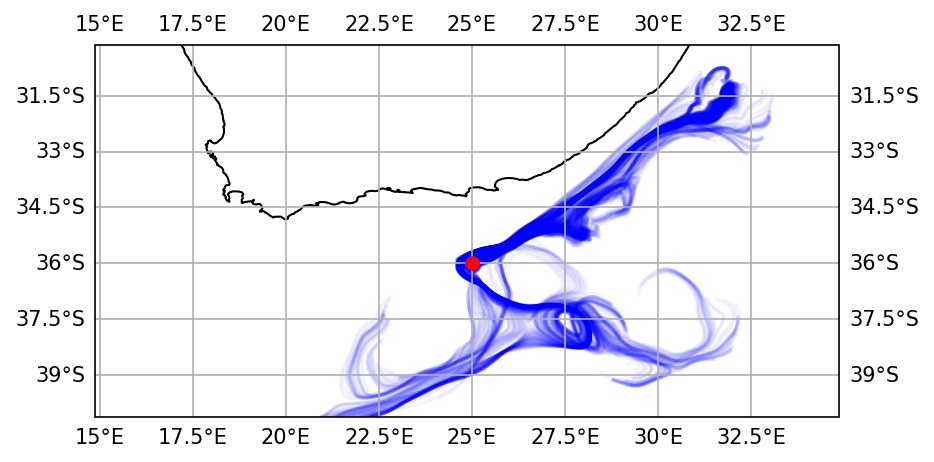

In [11]:
fig, ax = plt.subplots(1, 1, subplot_kw={"projection": cartopy.crs.PlateCarree()})
fig.set_dpi(150)
for n in range(ds.sizes["trajectory"]):
    ax.plot(
        *ds.isel(trajectory=n)[["lon", "lat"]].dropna("obs").data_vars.values(),
        color="b", alpha=0.05,
        transform=cartopy.crs.PlateCarree(),
    )
ax.coastlines()
ax.set_extent([
    np.min(fieldset.U.grid.lon),
    np.max(fieldset.U.grid.lon),
    np.min(fieldset.U.grid.lat),
    np.max(fieldset.U.grid.lat),
])
ax.gridlines(draw_labels=True);
plt.plot(lon_bds, lat_bds, "ro")